In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier
import xgboost as xgb
from imblearn.over_sampling import SMOTE, RandomOverSampler
from sklearn.utils.class_weight import compute_sample_weight
from collections import Counter

### The Problem

Identify which factors predict future user adoption.

"adopted user" is a user who has logged into the product on three seperate days in at least one seven-day period

In [157]:
df_engagement = pd.read_csv("../takehome_user_engagement.csv")
df_engagement.head()

,time_stamp,user_id,visited
0,2014-04-22 03:53:30,1,1
1,2013-11-15 03:45:04,2,1
2,2013-11-29 03:45:04,2,1
3,2013-12-09 03:45:04,2,1
4,2013-12-25 03:45:04,2,1


In [158]:
# find which users are adopted users
df_engagement['time_stamp'] = pd.to_datetime(df_engagement['time_stamp'])
df_engagement['date'] = df_engagement['time_stamp'].dt.date

df_engagement.head()
adopted_users = set()
for user_id, user_data in df_engagement.groupby('user_id'):
    user_data = user_data.sort_values('time_stamp')
    user_data = user_data.drop_duplicates(subset=['date'])
    user_data = user_data.reset_index(drop=True)
    for i in range(len(user_data) - 2):
        if (user_data.loc[i + 2, 'time_stamp'] - user_data.loc[i, 'time_stamp']).days <= 7:
            adopted_users.add(user_id)
            break

In [159]:
# our adopted users
print(len(adopted_users))
print(adopted_users)

1656
{8192, 2, 8196, 8201, 10, 20, 8214, 8217, 8220, 8221, 33, 8232, 8233, 42, 43, 8235, 8239, 50, 8243, 53, 60, 8252, 63, 8255, 8258, 8259, 69, 8265, 74, 8270, 80, 81, 82, 8277, 8278, 87, 8280, 8294, 8297, 8310, 8311, 8319, 133, 135, 141, 8334, 146, 153, 8348, 160, 165, 168, 172, 174, 8366, 8371, 185, 188, 8381, 8383, 197, 200, 8393, 202, 203, 8394, 8399, 209, 8401, 8403, 214, 8408, 8415, 230, 8426, 8435, 245, 247, 8440, 8442, 8448, 263, 265, 8460, 8463, 8466, 275, 280, 283, 297, 298, 8493, 305, 310, 311, 8505, 8507, 8508, 8511, 321, 322, 8523, 341, 345, 8538, 347, 351, 8553, 362, 363, 370, 8569, 8571, 383, 8581, 397, 401, 8593, 8595, 8601, 8602, 418, 8615, 430, 8622, 445, 8639, 8640, 450, 460, 462, 8654, 469, 471, 472, 478, 479, 8673, 483, 8675, 8677, 8679, 492, 494, 497, 8689, 502, 8695, 506, 509, 510, 8701, 512, 8704, 8706, 8708, 518, 520, 8712, 522, 529, 8721, 8725, 535, 540, 547, 8740, 8741, 553, 8749, 8750, 564, 8760, 572, 8767, 8768, 8769, 8770, 8779, 589, 591, 8789, 8790, 601,

In [160]:
df_users = pd.read_csv('../takehome_users.csv', encoding = "latin1")
df_users.head()

,object_id,creation_time,name,email,creation_source,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id
0,1,2014-04-22 03:53:30,Clausen August,AugustCClausen@yahoo.com,GUEST_INVITE,1.398139e+09,1,0,11,10803.0
1,2,2013-11-15 03:45:04,Poole Matthew,MatthewPoole@gustr.com,ORG_INVITE,1.396238e+09,0,0,1,316.0
2,3,2013-03-19 23:14:52,Bottrill Mitchell,MitchellBottrill@gustr.com,ORG_INVITE,1.363735e+09,0,0,94,1525.0
3,4,2013-05-21 08:09:28,Clausen Nicklas,NicklasSClausen@yahoo.com,GUEST_INVITE,1.369210e+09,0,0,1,5151.0
4,5,2013-01-17 10:14:20,Raw Grace,GraceRaw@yahoo.com,GUEST_INVITE,1.358850e+09,0,0,193,5240.0


In [161]:
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   object_id                   12000 non-null  int64  
 1   creation_time               12000 non-null  object 
 2   name                        12000 non-null  object 
 3   email                       12000 non-null  object 
 4   creation_source             12000 non-null  object 
 5   last_session_creation_time  8823 non-null   float64
 6   opted_in_to_mailing_list    12000 non-null  int64  
 7   enabled_for_marketing_drip  12000 non-null  int64  
 8   org_id                      12000 non-null  int64  
 9   invited_by_user_id          6417 non-null   float64
dtypes: float64(2), int64(4), object(4)
memory usage: 937.6+ KB


In [162]:
df_users['creation_time'] = pd.to_datetime(df_users['creation_time'])
df_users['name'] = df_users['name'].astype('string')
df_users['email'] = df_users['email'].astype('string')
df_users['last_session_creation_time'] = pd.to_datetime(df_users['last_session_creation_time'])
df_users['creation_source'] = df_users['creation_source'].astype('string')
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   object_id                   12000 non-null  int64         
 1   creation_time               12000 non-null  datetime64[ns]
 2   name                        12000 non-null  string        
 3   email                       12000 non-null  string        
 4   creation_source             12000 non-null  string        
 5   last_session_creation_time  8823 non-null   datetime64[ns]
 6   opted_in_to_mailing_list    12000 non-null  int64         
 7   enabled_for_marketing_drip  12000 non-null  int64         
 8   org_id                      12000 non-null  int64         
 9   invited_by_user_id          6417 non-null   float64       
dtypes: datetime64[ns](2), float64(1), int64(4), string(3)
memory usage: 937.6 KB


In [163]:
#change invited_by_user_id null values to 0 because there is no user with id 0
# last_session_creation_time has null values, but we will leave them as is for now

df_users['invited_by_user_id'] = df_users['invited_by_user_id'].fillna('0')
df_users.isnull().sum()

object_id                        0
creation_time                    0
name                             0
email                            0
creation_source                  0
last_session_creation_time    3177
opted_in_to_mailing_list         0
enabled_for_marketing_drip       0
org_id                           0
invited_by_user_id               0
dtype: int64

In [164]:
# now we will add a column to df_users to indicate if the user is an adopted user
df_users['is_adopted'] = df_users['object_id'].apply(lambda x: 1 if x in adopted_users else 0)  

In [165]:
df_users.head()


,object_id,creation_time,name,email,creation_source,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id,is_adopted
0,1,2014-04-22 03:53:30,Clausen August,AugustCClausen@yahoo.com,GUEST_INVITE,1970-01-01 00:00:01.398138810,1,0,11,10803.0,0
1,2,2013-11-15 03:45:04,Poole Matthew,MatthewPoole@gustr.com,ORG_INVITE,1970-01-01 00:00:01.396237504,0,0,1,316.0,1
2,3,2013-03-19 23:14:52,Bottrill Mitchell,MitchellBottrill@gustr.com,ORG_INVITE,1970-01-01 00:00:01.363734892,0,0,94,1525.0,0
3,4,2013-05-21 08:09:28,Clausen Nicklas,NicklasSClausen@yahoo.com,GUEST_INVITE,1970-01-01 00:00:01.369210168,0,0,1,5151.0,0
4,5,2013-01-17 10:14:20,Raw Grace,GraceRaw@yahoo.com,GUEST_INVITE,1970-01-01 00:00:01.358849660,0,0,193,5240.0,0


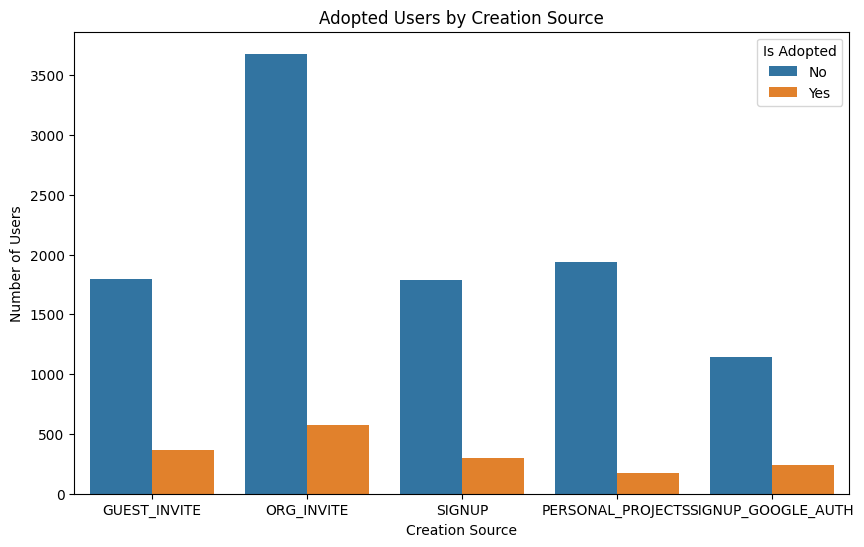

In [166]:
# make a graph of adopted users grouped by creation source
plt.figure(figsize=(10, 6))
sns.countplot(data=df_users, x='creation_source', hue='is_adopted')
plt.title('Adopted Users by Creation Source')
plt.xlabel('Creation Source')
plt.ylabel('Number of Users')
plt.legend(title='Is Adopted', labels=['No', 'Yes'])
plt.show()

In [167]:
# show percentage of users compared to creation source
source_percent = df_users['creation_source'].value_counts(normalize=True)*100
print(source_percent)

creation_source
ORG_INVITE                35.45
GUEST_INVITE             18.025
PERSONAL_PROJECTS     17.591667
SIGNUP                17.391667
SIGNUP_GOOGLE_AUTH    11.541667
Name: proportion, dtype: Float64


In [168]:
#make a column for 'invite_org' that shows the organization ID if user had an org_invite
df_users['invite_org_id'] = None

# Use .loc to assign the 'org_ID' value where the condition is True
df_users.loc[df_users['creation_source'] == 'org_invite', 'invite_org_id'] = df_users['org_id']

In [169]:
# fix some data types
df_users['invite_org_id'] = df_users['invite_org_id'].fillna('0')
df_users['invite_org_id'] = df_users['invite_org_id'].astype('int64')
df_users['invited_by_user_id'] = df_users['invited_by_user_id'].astype('int64')
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   object_id                   12000 non-null  int64         
 1   creation_time               12000 non-null  datetime64[ns]
 2   name                        12000 non-null  string        
 3   email                       12000 non-null  string        
 4   creation_source             12000 non-null  string        
 5   last_session_creation_time  8823 non-null   datetime64[ns]
 6   opted_in_to_mailing_list    12000 non-null  int64         
 7   enabled_for_marketing_drip  12000 non-null  int64         
 8   org_id                      12000 non-null  int64         
 9   invited_by_user_id          12000 non-null  int64         
 10  is_adopted                  12000 non-null  int64         
 11  invite_org_id               12000 non-null  int64     

In [170]:
# check to see if user invites are sent to other users at the same organization.
merged_df = df_users.merge(
    df_users,
    how='left',
    left_on=['invited_by_user_id', 'invite_org_id'],
    right_on=['object_id', 'org_id'],
    suffixes=('_inviter', '_invited')
)


In [171]:
#make a new column that shows if invited_by_user_ID and org_invite and org_ID == object_ID and org_ID
merged_df['is_matching_invite'] = merged_df['object_id_invited'].notna()
df_users['is_matching_invite'] = merged_df['is_matching_invite']

In [172]:
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   object_id                   12000 non-null  int64         
 1   creation_time               12000 non-null  datetime64[ns]
 2   name                        12000 non-null  string        
 3   email                       12000 non-null  string        
 4   creation_source             12000 non-null  string        
 5   last_session_creation_time  8823 non-null   datetime64[ns]
 6   opted_in_to_mailing_list    12000 non-null  int64         
 7   enabled_for_marketing_drip  12000 non-null  int64         
 8   org_id                      12000 non-null  int64         
 9   invited_by_user_id          12000 non-null  int64         
 10  is_adopted                  12000 non-null  int64         
 11  invite_org_id               12000 non-null  int64     

In [173]:
df_users['is_matching_invite'].value_counts()

is_matching_invite
False    11841
True       159
Name: count, dtype: int64

Creation source doesn't show much corrilation with adopted users, but compared to total users, there is an average adopted user retention for each catagory I feel. Also over 1/3 of users are due to organization invites. Also 159 users were invitied by a coworker.

In [174]:
# one hot encode lables for creation_source, org_id, and invited_by_user_id
df_users = pd.get_dummies(df_users, columns=['creation_source'], drop_first=False)

# drop name, email, invite_org_id columns
df_users = df_users.drop(columns=['name', 'email', 'invite_org_id'])

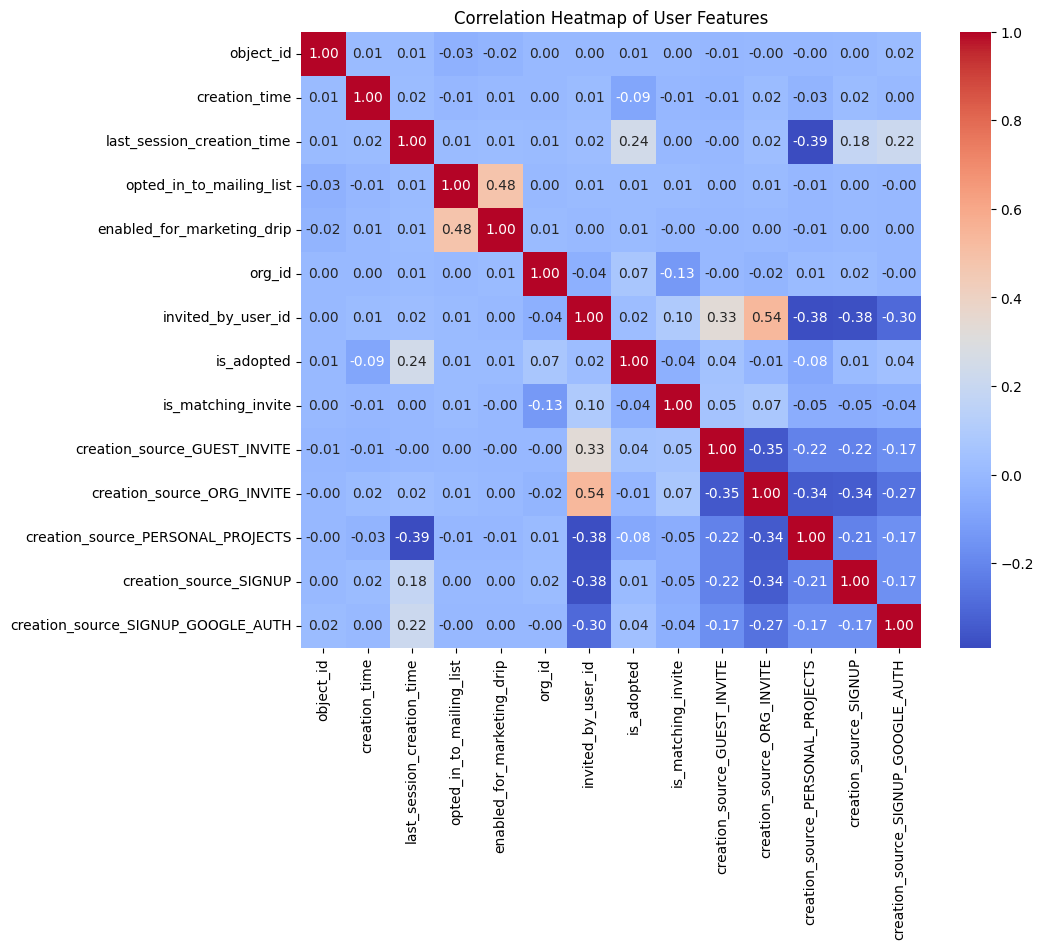

In [175]:
# create a heatmap to show correlation between features
plt.figure(figsize=(10, 8))
sns.heatmap(df_users.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of User Features')
plt.show()

The highest corrilations for an adopted users is creation time, Last session (because they are still active), org_id, invited_by_user_id, and creation_source.

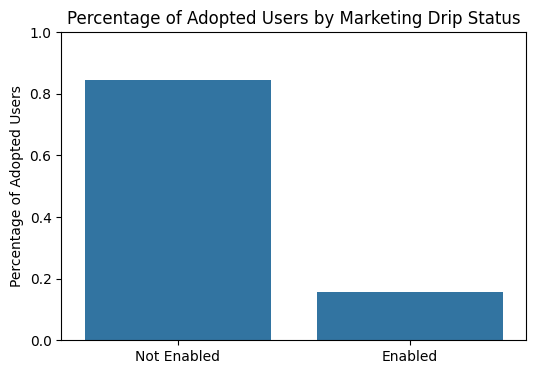

In [176]:
# make a graph of the percentage of adopted users that are enabled for marketing drip
plt.figure(figsize=(6, 4))
sns.barplot(x=['Not Enabled', 'Enabled'], y=[df_users[(df_users['enabled_for_marketing_drip'] == False) & (df_users['is_adopted'] == 1)].shape[0] / df_users[df_users['is_adopted'] == 1].shape[0], df_users[(df_users['enabled_for_marketing_drip'] == True) & (df_users['is_adopted'] == 1)].shape[0] / df_users[df_users['is_adopted'] == 1].shape[0]])
plt.ylabel('Percentage of Adopted Users')
plt.title('Percentage of Adopted Users by Marketing Drip Status')
plt.ylim(0, 1)
plt.show()

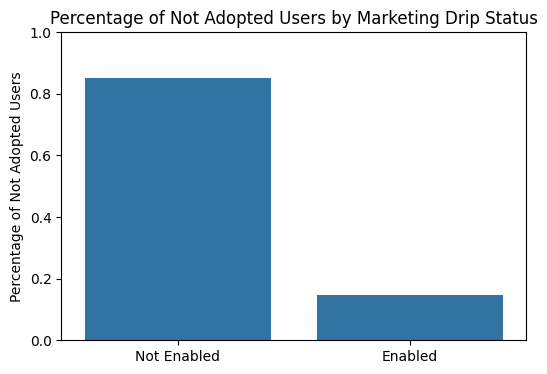

In [177]:
# make a graph of the percentage of adopted users that are enabled for marketing drip
plt.figure(figsize=(6, 4))
sns.barplot(x=['Not Enabled', 'Enabled'], y=[df_users[(df_users['enabled_for_marketing_drip'] == False) & (df_users['is_adopted'] == 0)].shape[0] / df_users[df_users['is_adopted'] == 0].shape[0], df_users[(df_users['enabled_for_marketing_drip'] == True) & (df_users['is_adopted'] == 0)].shape[0] / df_users[df_users['is_adopted'] == 0].shape[0]])
plt.ylabel('Percentage of Not Adopted Users')
plt.title('Percentage of Not Adopted Users by Marketing Drip Status')
plt.ylim(0, 1)
plt.show()

Marketing does not determin if someone is adopted. Adopted and not adpoted users both have the same subscription values. So the company shouldn't focus on their current marketing subscriptions to boost users

I think the strogest corrilation to predict adpoted users is the org_id that they belong to. But because there are so few adopted users compared to the total user base 1656/12000, about 1/10, it looks like rentention of users is generally low. The product is not popular, or it is only used by a few specific groups/people.

#### Data prep and modeling

In [178]:
# scale the data using StandardScaler

scaler = StandardScaler()
X = df_users.drop(columns=['object_id', 'is_adopted', 'creation_time', 'last_session_creation_time'])
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
y = df_users['is_adopted']
# Create a DataFrame to hold the features
feature_names = X.columns.tolist()



In [179]:
#split the data into training and testing sets

X_temp, X_test, y_temp, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [180]:
# we need to balance the classes because there are many more non-adopted users than adopted users
# we will use SMOTE to oversample the minority class
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_temp, y_temp)

In [181]:
# make a random forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_smote, y_smote)
y_pred = rf.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
#showing feature importances
importances = rf.feature_importances_
feature_importance_series = pd.Series(importances, index=feature_names)
sorted_importance = feature_importance_series.sort_values(ascending=False)
# Print the sorted feature importance
print("Feature Importances:")
print(sorted_importance)

[[1599  470]
 [ 239   92]]
              precision    recall  f1-score   support

           0       0.87      0.77      0.82      2069
           1       0.16      0.28      0.21       331

    accuracy                           0.70      2400
   macro avg       0.52      0.53      0.51      2400
weighted avg       0.77      0.70      0.73      2400

Feature Importances:
org_id                                0.674389
invited_by_user_id                    0.276813
creation_source_PERSONAL_PROJECTS     0.012505
opted_in_to_mailing_list              0.010560
enabled_for_marketing_drip            0.009241
creation_source_GUEST_INVITE          0.004044
creation_source_SIGNUP_GOOGLE_AUTH    0.003734
is_matching_invite                    0.003395
creation_source_ORG_INVITE            0.003051
creation_source_SIGNUP                0.002267
dtype: float64


In [182]:
#make XGBoost model
xgb_model = xgb.XGBClassifier(eval_metric='logloss')
xgb_model.fit(X_smote, y_smote)
y_pred_xgb = xgb_model.predict(X_test)
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
#showing feature importances
importances = xgb_model.feature_importances_

feature_importance_series = pd.Series(importances, index=feature_names)

sorted_importance = feature_importance_series.sort_values(ascending=False)

# Print the sorted feature importance
print("Feature Importances:")
print(sorted_importance)

[[1358  711]
 [ 196  135]]
              precision    recall  f1-score   support

           0       0.87      0.66      0.75      2069
           1       0.16      0.41      0.23       331

    accuracy                           0.62      2400
   macro avg       0.52      0.53      0.49      2400
weighted avg       0.78      0.62      0.68      2400

Feature Importances:
creation_source_PERSONAL_PROJECTS     0.243167
creation_source_SIGNUP                0.100790
org_id                                0.099479
creation_source_SIGNUP_GOOGLE_AUTH    0.093349
creation_source_ORG_INVITE            0.090522
enabled_for_marketing_drip            0.090129
invited_by_user_id                    0.085361
opted_in_to_mailing_list              0.079635
creation_source_GUEST_INVITE          0.076334
is_matching_invite                    0.041235
dtype: float32


In [183]:
# make a neural network model
mlp = MLPClassifier(hidden_layer_sizes=(50, 30), max_iter=500, random_state=42)
mlp.fit(X_smote, y_smote)
y_pred_mlp = mlp.predict(X_test)
print(confusion_matrix(y_test, y_pred_mlp))
print(classification_report(y_test, y_pred_mlp))

[[1036 1033]
 [ 144  187]]
              precision    recall  f1-score   support

           0       0.88      0.50      0.64      2069
           1       0.15      0.56      0.24       331

    accuracy                           0.51      2400
   macro avg       0.52      0.53      0.44      2400
weighted avg       0.78      0.51      0.58      2400



In [187]:
# try weighted classes in random forest and xgboost


sample_weights = compute_sample_weight(class_weight='balanced', y=y_temp)

In [188]:
# make a random forest model with balanced class weights
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_temp, y_temp, sample_weight=sample_weights)
y_pred = rf.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
#showing feature importances
importances = rf.feature_importances_

feature_importance_series = pd.Series(importances, index=feature_names)

sorted_importance = feature_importance_series.sort_values(ascending=False)

# Print the sorted feature importance
print("Feature Importances:")
print(sorted_importance)

[[1765  304]
 [ 272   59]]
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      2069
           1       0.16      0.18      0.17       331

    accuracy                           0.76      2400
   macro avg       0.51      0.52      0.51      2400
weighted avg       0.77      0.76      0.76      2400

Feature Importances:
org_id                                0.628068
invited_by_user_id                    0.311127
opted_in_to_mailing_list              0.014092
creation_source_PERSONAL_PROJECTS     0.013985
enabled_for_marketing_drip            0.013180
creation_source_GUEST_INVITE          0.004468
creation_source_SIGNUP_GOOGLE_AUTH    0.004416
creation_source_ORG_INVITE            0.004356
is_matching_invite                    0.003604
creation_source_SIGNUP                0.002703
dtype: float64


In [189]:
#make XGBoost model with balanced class weights
xgb_model = xgb.XGBClassifier(eval_metric='logloss')
xgb_model.fit(X_temp, y_temp, sample_weight=sample_weights)
y_pred_xgb = xgb_model.predict(X_test)
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
#showing feature importances
importances = xgb_model.feature_importances_

feature_importance_series = pd.Series(importances, index=feature_names)

sorted_importance = feature_importance_series.sort_values(ascending=False)

# Print the sorted feature importance
print("Feature Importances:")
print(sorted_importance)

[[1398  671]
 [ 206  125]]
              precision    recall  f1-score   support

           0       0.87      0.68      0.76      2069
           1       0.16      0.38      0.22       331

    accuracy                           0.63      2400
   macro avg       0.51      0.53      0.49      2400
weighted avg       0.77      0.63      0.69      2400

Feature Importances:
creation_source_PERSONAL_PROJECTS     0.224462
is_matching_invite                    0.110318
creation_source_ORG_INVITE            0.092064
org_id                                0.090236
invited_by_user_id                    0.084332
opted_in_to_mailing_list              0.083972
enabled_for_marketing_drip            0.081812
creation_source_SIGNUP_GOOGLE_AUTH    0.081231
creation_source_SIGNUP                0.076424
creation_source_GUEST_INVITE          0.075148
dtype: float32


In [190]:
# over sample the adopted class
oversampler = RandomOverSampler(random_state=42)
X_resampled_ros, y_resampled_ros = oversampler.fit_resample(X_scaled, y)
print(f"RandomOverSampler class distribution: {Counter(y_resampled_ros)}")

RandomOverSampler class distribution: Counter({0: 10344, 1: 10344})


In [191]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled_ros, y_resampled_ros, test_size=0.2, random_state=42)

In [192]:
# make a random forest model with oversampeling
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
#showing feature importances
importances = rf.feature_importances_

feature_importance_series = pd.Series(importances, index=feature_names)

sorted_importance = feature_importance_series.sort_values(ascending=False)

# Print the sorted feature importance
print("Feature Importances:")
print(sorted_importance)

[[1609  460]
 [ 128 1941]]
              precision    recall  f1-score   support

           0       0.93      0.78      0.85      2069
           1       0.81      0.94      0.87      2069

    accuracy                           0.86      4138
   macro avg       0.87      0.86      0.86      4138
weighted avg       0.87      0.86      0.86      4138

Feature Importances:
org_id                                0.619469
invited_by_user_id                    0.326520
creation_source_PERSONAL_PROJECTS     0.013956
opted_in_to_mailing_list              0.012140
enabled_for_marketing_drip            0.010624
creation_source_GUEST_INVITE          0.003956
is_matching_invite                    0.003837
creation_source_ORG_INVITE            0.003556
creation_source_SIGNUP_GOOGLE_AUTH    0.003541
creation_source_SIGNUP                0.002402
dtype: float64


In [194]:
#make XGBoost model with oversampeling
xgb_model = xgb.XGBClassifier(eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
#showing feature importances
importances = xgb_model.feature_importances_

feature_importance_series = pd.Series(importances, index=feature_names)

sorted_importance = feature_importance_series.sort_values(ascending=False)

# Print the sorted feature importance
print("Feature Importances:")
print(sorted_importance)

[[1391  678]
 [ 428 1641]]
              precision    recall  f1-score   support

           0       0.76      0.67      0.72      2069
           1       0.71      0.79      0.75      2069

    accuracy                           0.73      4138
   macro avg       0.74      0.73      0.73      4138
weighted avg       0.74      0.73      0.73      4138

Feature Importances:
is_matching_invite                    0.233497
creation_source_PERSONAL_PROJECTS     0.170420
creation_source_ORG_INVITE            0.102560
org_id                                0.080322
invited_by_user_id                    0.071528
creation_source_SIGNUP                0.070447
enabled_for_marketing_drip            0.068851
creation_source_GUEST_INVITE          0.068704
opted_in_to_mailing_list              0.068249
creation_source_SIGNUP_GOOGLE_AUTH    0.065422
dtype: float32


In [ ]:
# make a neural network model with oversampeling
mlp = MLPClassifier(hidden_layer_sizes=(50, 30), max_iter=500, random_state=42)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)
print(confusion_matrix(y_test, y_pred_mlp))
print(classification_report(y_test, y_pred_mlp))

[[1106  963]
 [ 693 1376]]
              precision    recall  f1-score   support

           0       0.61      0.53      0.57      2069
           1       0.59      0.67      0.62      2069

    accuracy                           0.60      4138
   macro avg       0.60      0.60      0.60      4138
weighted avg       0.60      0.60      0.60      4138



For modeling Random Forest, XGBoost, and MLPClassifier were tested. Becasue of unequal class sizes, 3 methods were used to equalize class representation: SMOTE, weighted classes, and oversampling. The three methods gave varied results.

XGBoost preformed best with SMOTE.
The weighted models underpreformed SMOTE.
Random forest preformed best with oversampeling.

I would contiune to develope the Random forest oversampeling model. Looking at the classifiaction reports and confusion matrixes, it looks like it preforms best out of all the models.

It uses the org_ID and invited_user_ID as the main predictive featrues.

If more data can be collected, I would suggest requesting information about jobs users have, or if they still work for the same organization. Data could also be collected on if they know of or use a competitor service. This info could improve model features.
